In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pickle
from typing import Literal
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse.csgraph as csgraph
import torch
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader

In [ ]:
# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
DATA_DIR = "/content/drive/MyDrive/CMPE-257/spatiotemporal-traffic-forecasting/datasets"
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15
window_size  = 12
horizon      = 12
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size   = 32
in_feats     = window_size
temporal_hidden = 32
hidden_feats = 64
out_feats    = horizon
num_layers   = 3
num_heads    = 4
dropout      = 0.3
lr           = 1e-3
epochs       = 25
print_every  = 100

In [ ]:
# data.py

DATASET_CONFIG = {
    "METR-LA": {
        "group_key": "df",
        "h5_path":  f"{DATA_DIR}/raw/metr_la/metr_la.h5",
        "adj_path": f"{DATA_DIR}/raw/metr_la/adj_metr_la.pkl",
        "meta_path": None,
        "pyg_path": f"{DATA_DIR}/processed/metr_la/metr_la.pt",
    },
    "PEMS-BAY": {
        "group_key": "speed",
        "h5_path":  f"{DATA_DIR}/raw/pems_bay/pems_bay.h5",
        "adj_path": f"{DATA_DIR}/raw/pems_bay/adj_mx_bay.pkl",
        "meta_path": f"{DATA_DIR}/raw/pems_bay/pems_bay_meta.h5",
        "pyg_path": f"{DATA_DIR}/processed/pems_bay/pems_bay.pt",
    },
}

def load_traffic_h5(dataset: Literal["METR-LA", "PEMS-BAY"]) -> pd.DataFrame:
    config = DATASET_CONFIG[dataset]

    with h5py.File(config["h5_path"], "r") as f:
        group = f[config["group_key"]]
        values = group["block0_values"][:]
        sensor_ids = group["axis0"][:]
        timestamps = group["axis1"][:]

    times = pd.to_datetime(timestamps, unit="ns")
    N = len(sensor_ids)
    if values.shape[0] == N:
        values = values.T

    df = pd.DataFrame(values, index=times, columns=sensor_ids)
    df.columns = df.columns.astype(str) # sensor IDs to str as sensor ID to idx map uses string IDs

    return df


def load_adj_data(dataset: Literal["METR-LA", "PEMS-BAY"]):
    """
    Returns:
        sensor_ids        : list of sensor ID strings, length N
        sensor_id_to_idx  : dict mapping sensor ID → node index (0..N-1)
        adj_mx            : np.ndarray, shape (N, N), weights in [0, 1]
    """
    config = DATASET_CONFIG[dataset]

    with open(config["adj_path"], "rb") as f:
        adj_data = pickle.load(f, encoding="latin1")

    sensor_ids, sensor_id_to_idx, adj_mx = adj_data

    return sensor_ids, sensor_id_to_idx, adj_mx

def interpolate_speed(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replaces zeros with NaN and linearly interpolates along time axis.

    Args:
        df     : pd.DataFrame, shape (T, N), raw speed data
        dataset: dataset name for logging

    Returns:
        pd.DataFrame, shape (T, N), interpolated speed data
    """
    before_zeros = (df == 0).sum().sum()

    df_interp = df.copy()
    df_interp[df_interp == 0] = np.nan
    df_interp = df_interp.interpolate(method='linear', axis=0, limit_direction='both')

    remaining_nans = df_interp.isna().sum().sum()

    print(f"zeros replaced : {before_zeros}")
    print(f"remaining NaNs : {remaining_nans}")

    return df_interp

def normalize(df: pd.DataFrame):
    """Z-score normalization using global mean and std."""
    mean = df.values.mean()
    std  = df.values.std()
    return (df - mean) / std, mean, std

# ─────────────────────────────────────────
# ADJACENCY → edge_index + edge_attr
# ─────────────────────────────────────────
def build_edge_index_and_attr(adj_mx: np.ndarray):
    """
    Converts adjacency matrix to PyG edge_index and edge_attr.
    Sensor IDs are already mapped to 0..N-1 via adj_mx row/col indices.

    Returns:
        edge_index : torch.LongTensor,  shape [2, num_edges]
        edge_attr  : torch.FloatTensor, shape [num_edges, 1]
    """
    adj_tensor = torch.tensor(adj_mx, dtype=torch.float)
    edge_index  = adj_tensor.nonzero().t().contiguous()   # [2, num_edges]

    # remove self-loops
    mask       = edge_index[0] != edge_index[1]
    edge_index = edge_index[:, mask]

    # edge weights as attributes
    edge_attr  = adj_tensor[edge_index[0], edge_index[1]].unsqueeze(1)  # [num_edges, 1]

    print(f"edge_index : {edge_index.shape}")
    print(f"edge_attr  : {edge_attr.shape}")
    return edge_index, edge_attr

# ─────────────────────────────────────────
# SLIDING WINDOW → list of PyG Data objects
# ─────────────────────────────────────────
def build_pyg_data_list(
    speed:      torch.Tensor,    # (T, N) normalized speed
    edge_index: torch.Tensor,    # (2, E)
    edge_attr:  torch.Tensor,    # (E, 1)
    window_size: int,
    horizon:     int,
) -> list:
    """
    Creates one PyG Data object per sliding window:
        x : [N, window_size]  — past speeds (input)
        y : [N, horizon]      — future speeds (target)
    Node indices are 0..N-1, matching adj_mx row/col order.
    """
    data_list = []
    T = speed.shape[0]

    for t in range(window_size - 1, T - horizon):
        x = speed[t - window_size + 1 : t + 1].T        # [N, window_size]
        y = speed[t + 1           : t + 1 + horizon].T  # [N, horizon]
        data_list.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y))

    print(f"total samples : {len(data_list)}")
    print(f"x shape       : {data_list[0].x.shape}")
    print(f"y shape       : {data_list[0].y.shape}")
    return data_list

# ─────────────────────────────────────────
# TRAIN / VAL / TEST SPLIT
# ─────────────────────────────────────────
def split_data_list(data_list: list, train_ratio=train_ratio, val_ratio=val_ratio):
    """
    Splits data_list temporally (no shuffle — time series).

    Returns:
        train_list, val_list, test_list
    """
    N      = len(data_list)
    t_end  = int(N * train_ratio)
    v_end  = int(N * (train_ratio + val_ratio))

    train  = data_list[:t_end]
    val    = data_list[t_end:v_end]
    test   = data_list[v_end:]

    print(f"train : {len(train)} samples")
    print(f"val   : {len(val)} samples")
    print(f"test  : {len(test)} samples")
    return train, val, test

# ─────────────────────────────────────────
# PyG DATASET WRAPPER
# ─────────────────────────────────────────
class TrafficDataset(InMemoryDataset):
    def __init__(self, data_list):
        super().__init__()
        self.data_list = data_list

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

def build_dataset(dataset: Literal["METR-LA", "PEMS-BAY"]):
    pyg_path = DATASET_CONFIG[dataset]["pyg_path"]
    os.makedirs(os.path.dirname(pyg_path), exist_ok=True)

    print(f"\n{'='*40}")
    print(f" {dataset}")
    print(f"{'='*40}")

    # 1. load
    print("\n[1] loading speed data")
    df = load_traffic_h5(dataset)

    # 2. interpolate
    print("\n[2] interpolating missing values")
    df = interpolate_speed(df)

    # 3. split raw df first (before normalization)
    print("\n[3] splitting")
    n     = len(df)
    t_end = int(n * train_ratio)
    v_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:t_end]
    val_df   = df.iloc[t_end:v_end]
    test_df  = df.iloc[v_end:]

    print(f"train : {len(train_df)} | val : {len(val_df)} | test : {len(test_df)}")

    # 4. normalize — fit only on train, apply to all
    print("\n[4] normalizing")
    mean = train_df.values.mean()
    std  = train_df.values.std()
    print(f"mean={mean:.3f}  std={std:.3f}")

    train_df = (train_df - mean) / std
    val_df   = (val_df   - mean) / std
    test_df  = (test_df  - mean) / std

    # 5. adjacency
    print("\n[5] loading adjacency matrix")
    sensor_ids, sensor_id_to_idx, adj_mx = load_adj_data(dataset)
    edge_index, edge_attr = build_edge_index_and_attr(adj_mx)

    # 6. sliding windows per split
    print("\n[6] building sliding windows")
    def to_tensor(d): return torch.tensor(d.values, dtype=torch.float32)

    train_list = build_pyg_data_list(to_tensor(train_df), edge_index, edge_attr, window_size, horizon)
    val_list   = build_pyg_data_list(to_tensor(val_df),   edge_index, edge_attr, window_size, horizon)
    test_list  = build_pyg_data_list(to_tensor(test_df),  edge_index, edge_attr, window_size, horizon)

    # 7. save
    torch.save({
        "train": train_list,
        "val":   val_list,
        "test":  test_list,
        "mean":  mean,
        "std":   std,
    }, pyg_path)
    print(f"\nsaved → {pyg_path}")

    return TrafficDataset(train_list), TrafficDataset(val_list), TrafficDataset(test_list), mean, std



In [ ]:
# usage
metr_df = load_traffic_h5("METR-LA")
metr_sensor_ids, metr_sensor_id_to_idx, metr_adj_mx = load_adj_data("METR-LA")
metr_df_interp = interpolate_speed(metr_df)
# print("METR-LA:", len(metr_sensor_ids), metr_adj_mx.shape, list(metr_sensor_id_to_idx.items())[:3])

# check adjacency matrix indices and speed dataframe sensor ID columns alignment
df_indices = [metr_sensor_id_to_idx[s] for s in metr_df.columns]
aligned = df_indices == list(range(len(df_indices)))
# print("METR-LA: Columns aligned to adjacency:", aligned)

# build dataset
train_metr, val_metr, test_metr, mean, std = build_dataset("METR-LA")

# ─────────────────────────────────────────
train_loader = DataLoader(train_metr, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_metr, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_metr, batch_size=batch_size, shuffle=False)



zeros replaced : 575302
remaining NaNs : 0

 METR-LA

[1] loading speed data

[2] interpolating missing values
zeros replaced : 575302
remaining NaNs : 0

[3] splitting
train : 23990 | val : 5141 | test : 5141

[4] normalizing
mean=58.452  std=12.855

[5] loading adjacency matrix
edge_index : torch.Size([2, 1515])
edge_attr  : torch.Size([1515, 1])

[6] building sliding windows
total samples : 23967
x shape       : torch.Size([207, 12])
y shape       : torch.Size([207, 12])
total samples : 5118
x shape       : torch.Size([207, 12])
y shape       : torch.Size([207, 12])
total samples : 5118
x shape       : torch.Size([207, 12])
y shape       : torch.Size([207, 12])

saved → /content/drive/MyDrive/CMPE-257/spatiotemporal-traffic-forecasting/datasets/processed/metr_la/metr_la.pt


In [ ]:
# train.py

def train(model, train_loader, val_loader, optimizer, criterion, device,
          epochs, print_every=100, scheduler=None):

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch    = 0

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        # ── train ──
        model.train()
        total_loss   = 0.0
        running_loss = 0.0

        for step, batch in enumerate(train_loader, 1):
            batch  = batch.to(device)
            optimizer.zero_grad()
            loss   = criterion(model(batch), batch.y)
            loss.backward()
            optimizer.step()
            total_loss   += loss.item()
            running_loss += loss.item()
            if step % print_every == 0:
                print(f"  step {step:4d} | loss {running_loss / print_every:.4f}")
                running_loss = 0.0

        train_loss = total_loss / len(train_loader)

        # ── eval ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch     = batch.to(device)
                val_loss += criterion(model(batch), batch.y).item()
        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            torch.save(model.state_dict(), "best_model.pt")

        print(f"  train loss : {train_loss:.4f}")
        print(f"  val loss   : {val_loss:.4f}  {'← best' if epoch == best_epoch else ''}")

    print(f"\nbest val loss : {best_val_loss:.4f} at epoch {best_epoch}")
    return train_losses, val_losses

In [ ]:
# eval.py, test.py

def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

def test(model, test_loader, mean, std, device):
    all_preds, all_targets = [], []

    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out   = model(batch)
            all_preds.append(out.cpu())
            all_targets.append(batch.y.cpu())

    all_preds   = torch.cat(all_preds,   dim=0)   # [T*N, horizon]
    all_targets = torch.cat(all_targets, dim=0)   # [T*N, horizon]

    # denormalize
    all_preds_denorm   = all_preds   * std + mean
    all_targets_denorm = all_targets * std + mean

    # metrics
    mse  = torch.mean((all_preds_denorm - all_targets_denorm) ** 2)
    rmse = torch.sqrt(mse)
    mae  = torch.mean(torch.abs(all_preds_denorm - all_targets_denorm))

    print(f"rmse : {rmse:.4f}")
    print(f"mae  : {mae:.4f}")

    return all_preds_denorm, all_targets_denorm

In [ ]:
# model.py

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATv2Conv, GCNConv
from torch_geometric.nn.norm import LayerNorm

# Simple GCN Baseline

# class GCNBaseline(nn.Module):
#     def __init__(self, in_feats, hidden_feats, out_feats):
#         super().__init__()
#         self.conv1 = GCNConv(in_feats, hidden_feats)
#         self.conv2 = GCNConv(hidden_feats, hidden_feats)
#         self.fc = nn.Linear(hidden_feats, out_feats)

#     def forward(self, data):
#         x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

#         # edge_attr must be shape [num_edges]
#         # edge_weight = None
#         edge_weight = edge_attr.squeeze() if edge_attr is not None else None

#         x = F.relu(self.conv1(x, edge_index, edge_weight=edge_weight))
#         x = F.relu(self.conv2(x, edge_index, edge_weight=edge_weight))
#         x = self.fc(x)
#         return x

# Issues:
# 1. No temporal dynamics modeled (no RNN, no temporal convolution).
#    Past 12 timesteps are just flattened into a feature vector.
#    The model treats them all equally, ignoring causality or temporal importance.
# 2. Ignores time correlations, trends, seasonality.
# 3. Edge weights are fixed from distance / road network.

# class STGCNBaseline(nn.Module):
#     def __init__(self, in_feats, temporal_hidden, hidden_feats, out_feats):
#         super().__init__()
#         # GRU layer for temporal modeling
#         self.rnn = nn.GRU(input_size=1, hidden_size=temporal_hidden, batch_first=True)

#         self.conv1 = GCNConv(temporal_hidden, hidden_feats)
#         self.conv2 = GCNConv(hidden_feats, hidden_feats)
#         self.fc = nn.Linear(hidden_feats, out_feats)

#     def forward(self, data):
#         x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
#         edge_weight = edge_attr.squeeze() if edge_attr is not None else None

#         ### Addressing problem 1
#         # x shape: [num_nodes, 12] -> reshape to [num_nodes, seq_len=12, feature=1] for GRU
#         x_seq = x.unsqueeze(-1)  # [num_nodes, seq_len=12, features=1]
#         out, h_n = self.rnn(x_seq)  # GRU input_size=1
#         x = out[:, -1, :]           # last timestep embedding
#         ###

#         x = F.relu(self.conv1(x, edge_index, edge_weight=edge_weight))
#         x = F.relu(self.conv2(x, edge_index, edge_weight=edge_weight))
#         x = self.fc(x)
#         return x

# Issues STGCN using GRU/RNN:
# 1. Vanilla GRU treats all past hidden states uniformly when producing output (or just uses last hidden state)
#    Recent timesteps might be more important than older ones, but the model has no explicit attention over time

class STGCNAttentionBaseline(nn.Module):
    def __init__(self, in_feats=1, temporal_hidden=32, hidden_feats=32, out_feats=1, num_heads=4):
        super().__init__()
        # project scalar timestep → temporal_hidden so MultiheadAttention has proper embedding
        self.input_proj = nn.Linear(1, temporal_hidden)

        # transformer-style attention over the 12 timesteps
        self.attn = nn.MultiheadAttention(
            embed_dim=temporal_hidden,
            num_heads=num_heads,
            batch_first=True,  # keeps [N, seq_len, embed_dim] format
        )
        self.norm = nn.LayerNorm(temporal_hidden)

        # GCN layers for spatial aggregation
        self.conv1 = GCNConv(temporal_hidden, hidden_feats)
        self.conv2 = GCNConv(hidden_feats, hidden_feats)
        self.fc    = nn.Linear(hidden_feats, out_feats)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        edge_weight = edge_attr.squeeze() if edge_attr is not None else None

        # x: [num_nodes, seq_len] → [num_nodes, seq_len, 1] for input projection
        x_seq = x.unsqueeze(-1)
        x_seq = self.input_proj(x_seq)  # [num_nodes, seq_len, temporal_hidden]

        # self-attention over timesteps
        attn_out, _ = self.attn(x_seq, x_seq, x_seq)  # [num_nodes, seq_len, temporal_hidden]
        x_seq = self.norm(attn_out + x_seq)

        x = x_seq[:, -1, :]  # [num_nodes, temporal_hidden], take last timestep embedding
        # x = x_seq.mean(dim=1) # use temporal pooling instead

        x = F.relu(self.conv1(x, edge_index, edge_weight=edge_weight))
        x = F.relu(self.conv2(x, edge_index, edge_weight=edge_weight))
        x = self.fc(x)

        return x

  # Issues:
  # 1. Edge weights are still fixed; no explicit spatial attention.
  # 2. Last timestep selection may ignore useful temporal info. Switch to temporal pooling

In [ ]:
# usage

# model = GCNBaseline(in_feats, hidden_feats, out_feats).to(device)
# model = STGCNBaseline(in_feats, temporal_hidden, hidden_feats, out_feats).to(device)
model = STGCNAttentionBaseline(in_feats, temporal_hidden, hidden_feats, out_feats, num_heads).to(device)

# MSE/RMSE — squares large errors, so one bad outlier (a sensor spike during an accident) can dominate the entire gradient update and destabilize training
# MAE — robust to outliers but has a non-smooth gradient at zero, which makes optimization harder and convergence slower
# HuberLoss — best of both: smooth gradients like MSE for normal predictions, outlier resistance like MAE for spikes

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs,
    print_every=print_every,
    scheduler=scheduler
)

Model parameters: 11,404

Epoch 1/25
  step  100 | loss 0.2644
  step  200 | loss 0.2325
  step  300 | loss 0.2284
  train loss : 0.2393
  val loss   : 0.2278  ← best

Epoch 2/25
  step  100 | loss 0.2305
  step  200 | loss 0.2275
  step  300 | loss 0.2317
  train loss : 0.2291
  val loss   : 0.2255  ← best

Epoch 3/25
  step  100 | loss 0.2309
  step  200 | loss 0.2248
  step  300 | loss 0.2256
  train loss : 0.2271
  val loss   : 0.2233  ← best

Epoch 4/25
  step  100 | loss 0.2263
  step  200 | loss 0.2276
  step  300 | loss 0.2232
  train loss : 0.2252
  val loss   : 0.2223  ← best

Epoch 5/25
  step  100 | loss 0.2257
  step  200 | loss 0.2213
  step  300 | loss 0.2216
  train loss : 0.2218
  val loss   : 0.2168  ← best

Epoch 6/25
  step  100 | loss 0.2187
  step  200 | loss 0.2172
  step  300 | loss 0.2175
  train loss : 0.2185
  val loss   : 0.2148  ← best

Epoch 7/25
  step  100 | loss 0.2176
  step  200 | loss 0.2177
  step  300 | loss 0.2148
  train loss : 0.2165
  val loss 

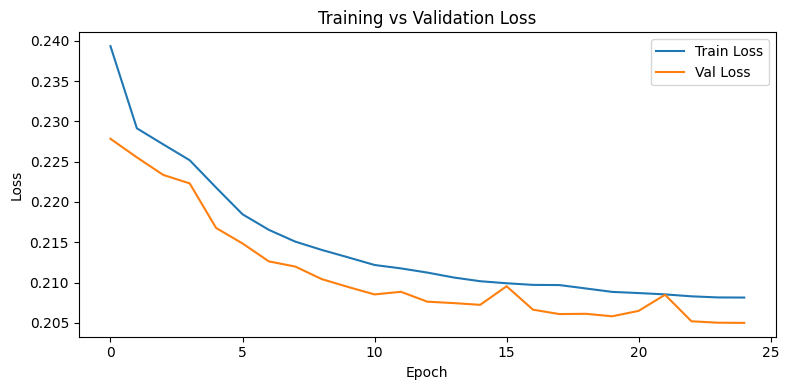

rmse : 9.7864
mae  : 6.0912


In [ ]:
plot_losses(train_losses, val_losses)
preds, targets = test(model, test_loader, mean, std, device)

In [ ]:
class GraphSage(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_layers=3, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.hidden_feats = hidden_feats

        # Input layer
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.res_projs = nn.ModuleList()  # For residual projections

        # First layer
        self.convs.append(SAGEConv(in_feats, hidden_feats))
        self.norms.append(LayerNorm(hidden_feats))
        self.res_projs.append(nn.Linear(in_feats, hidden_feats))  # project input to hidden_feats

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_feats, hidden_feats))
            self.norms.append(LayerNorm(hidden_feats))
            self.res_projs.append(nn.Identity())  # hidden_feats → hidden_feats, identity

        # Output layer
        self.convs.append(SAGEConv(hidden_feats, hidden_feats))
        self.norms.append(LayerNorm(hidden_feats))
        self.res_projs.append(nn.Identity())

        # Final fully connected layer to predict horizon
        self.fc = nn.Linear(hidden_feats, out_feats)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        # SAGEConv does not support edge_weight
        # edge_weight = edge_attr.squeeze() if edge_attr is not None else None

        for i in range(self.num_layers):
            residual = self.res_projs[i](x)  # project residual to match hidden_feats
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual

        x = self.fc(x)
        return x

In [ ]:
# Instantiate model
model = GraphSage(
    in_feats=in_feats,
    hidden_feats=hidden_feats,
    out_feats=out_feats,
    num_layers=num_layers,
    dropout=dropout
).to(device)

# Optimizer, criterion, scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ---------------------------
# 2️⃣ Train the model
# ---------------------------
train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs,
    print_every=print_every,
    scheduler=scheduler
)

Model parameters: 20,108

Epoch 1/5
  step  100 | loss 0.1993
  step  200 | loss 0.1280
  step  300 | loss 0.1148
  step  400 | loss 0.1151
  step  500 | loss 0.1118
  step  600 | loss 0.1113
  step  700 | loss 0.1073
  train loss : 0.1256
  val loss   : 0.1026  ← best

Epoch 2/5
  step  100 | loss 0.1113
  step  200 | loss 0.1090
  step  300 | loss 0.1068
  step  400 | loss 0.1058
  step  500 | loss 0.1084
  step  600 | loss 0.1059
  step  700 | loss 0.1068
  train loss : 0.1077
  val loss   : 0.1003  ← best

Epoch 3/5
  step  100 | loss 0.1083
  step  200 | loss 0.1049
  step  300 | loss 0.1069
  step  400 | loss 0.1066
  step  500 | loss 0.1046
  step  600 | loss 0.1073
  step  700 | loss 0.1047
  train loss : 0.1061
  val loss   : 0.0977  ← best

Epoch 4/5
  step  100 | loss 0.1053
  step  200 | loss 0.1043
  step  300 | loss 0.1054
  step  400 | loss 0.1054
  step  500 | loss 0.1053
  step  600 | loss 0.1042
  step  700 | loss 0.1072
  train loss : 0.1053
  val loss   : 0.0979  



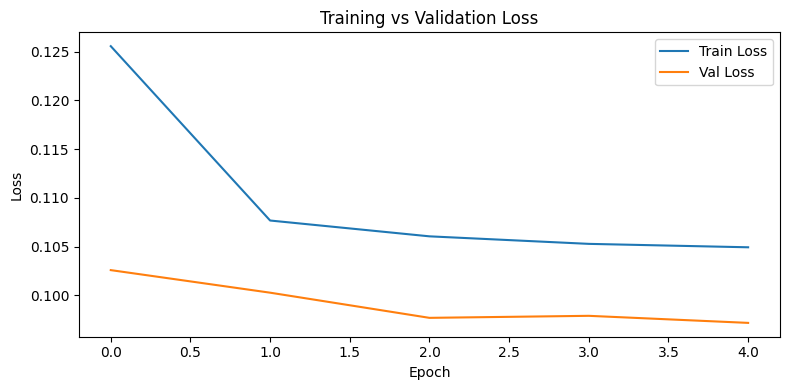

In [ ]:
plot_losses(train_losses, val_losses)
preds, targets = test(model, test_loader, mean, std, device)

In [ ]:
class TemporalBlock(nn.Module):
    """GRU-based temporal encoder — learns patterns across the input window."""
    def __init__(self, in_feats, hidden_feats, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = 1,
            hidden_size = hidden_feats,
            num_layers  = 2,
            batch_first = True,
            dropout     = dropout,
        )

    def forward(self, x):
        # x : [N, window_size]
        x = x.unsqueeze(-1)          # [N, window_size, 1]
        _, h = self.gru(x)           # h : [2, N, hidden]
        return h[-1]                 # [N, hidden]


class SpatialBlock(nn.Module):
    """GATv2 spatial layer — uses edge_index AND edge_attr as input to attention."""
    def __init__(self, hidden_feats, heads, dropout):
        super().__init__()
        assert hidden_feats % heads == 0, "hidden_feats must be divisible by heads"
        self.conv = GATv2Conv(
            in_channels       = hidden_feats,
            out_channels      = hidden_feats // heads,
            heads             = heads,
            edge_dim          = 1,        # edge_attr has 1 feature (Gaussian weight)
            dropout           = dropout,
            concat            = True,     # output = heads * (hidden // heads) = hidden
            add_self_loops    = False,    # already in adj_mx
        )
        self.norm    = LayerNorm(hidden_feats)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr):
        residual = x
        x = self.conv(x, edge_index, edge_attr=edge_attr)
        x = self.norm(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x + residual


class SpatioTemporalGNN(nn.Module):
    """
    Architecture:
        1. TemporalBlock  — GRU encodes time window → node embedding
        2. SpatialBlocks  — stacked GATv2 layers propagate spatial context
        3. FC head        — projects to forecast horizon

    Inputs (from PyG batch):
        data.x          : [N, window_size]
        data.edge_index : [2, E]
        data.edge_attr  : [E, 1]

    Output:
        [N, horizon]
    """
    def __init__(
        self,
        in_feats     : int,
        hidden_feats : int,
        out_feats    : int,
        num_layers   : int = 3,
        heads        : int = 4,
        dropout      : float = 0.3,
    ):
        super().__init__()

        # temporal encoder
        self.temporal = TemporalBlock(in_feats, hidden_feats, dropout)

        # spatial layers
        self.spatial = nn.ModuleList([
            SpatialBlock(hidden_feats, heads, dropout)
            for _ in range(num_layers)
        ])

        # output
        self.fc = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_feats, out_feats),
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        # 1. temporal encoding
        x = self.temporal(x)                              # [N, hidden]

        # 2. spatial propagation
        for layer in self.spatial:
            x = layer(x, edge_index, edge_attr)           # [N, hidden]

        # 3. predict
        return self.fc(x)                                 # [N, horizon]

In [ ]:
model     = SpatioTemporalGNN(in_feats, hidden_feats, out_feats, num_layers, num_heads, dropout).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)   # more robust to outliers than MSE
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

train_losses, val_losses = train(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=epochs, print_every=print_every,
    scheduler=scheduler,
)

parameters: 68,684

Epoch 1/5
  step  100 | loss 0.2273
  step  200 | loss 0.1367
  step  300 | loss 0.1257
  step  400 | loss 0.1192
  step  500 | loss 0.1155
  step  600 | loss 0.1168
  step  700 | loss 0.1185
  train loss : 0.1357
  val loss   : 0.1004  ← best

Epoch 2/5
  step  100 | loss 0.1130
  step  200 | loss 0.1157
  step  300 | loss 0.1145
  step  400 | loss 0.1130
  step  500 | loss 0.1142
  step  600 | loss 0.1126
  step  700 | loss 0.1143
  train loss : 0.1140
  val loss   : 0.1022  

Epoch 3/5
  step  100 | loss 0.1165
  step  200 | loss 0.1129
  step  300 | loss 0.1110
  step  400 | loss 0.1100
  step  500 | loss 0.1135
  step  600 | loss 0.1135
  step  700 | loss 0.1105
  train loss : 0.1123
  val loss   : 0.0991  ← best

Epoch 4/5
  step  100 | loss 0.1104
  step  200 | loss 0.1139
  step  300 | loss 0.1118
  step  400 | loss 0.1131
  step  500 | loss 0.1121
  step  600 | loss 0.1132
  step  700 | loss 0.1096
  train loss : 0.1117
  val loss   : 0.0987  ← best

Epoch 

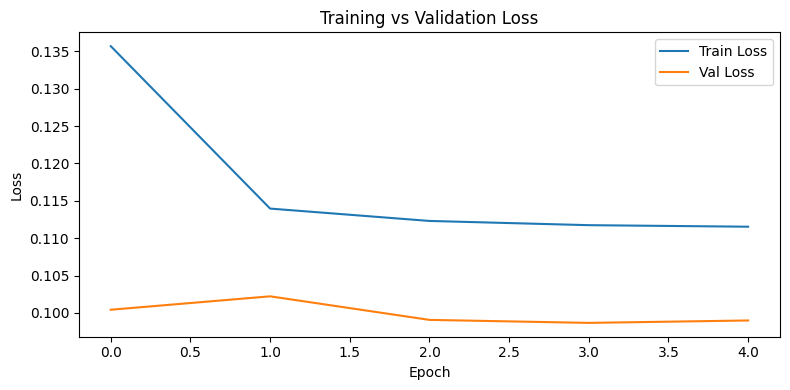

rmse : 6.9656
mae  : 3.6122


In [ ]:
plot_losses(train_losses, val_losses)
preds, targets = test(model, test_loader, mean, std, device)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj

class DiffusionConv(nn.Module):
    def __init__(self, hidden_feats):
        super().__init__()
        self.linear = nn.Linear(hidden_feats, hidden_feats)

    def forward(self, x, adj):
        return self.linear(torch.matmul(adj, x))


class DCGRUCell(nn.Module):
    def __init__(self, hidden_feats):
        super().__init__()
        self.hidden_feats = hidden_feats

        self.conv_z = DiffusionConv(hidden_feats)
        self.conv_r = DiffusionConv(hidden_feats)
        self.conv_h = DiffusionConv(hidden_feats)

    def forward(self, x, h, adj):
        z = torch.sigmoid(self.conv_z(x, adj) + self.conv_z(h, adj))
        r = torch.sigmoid(self.conv_r(x, adj) + self.conv_r(h, adj))
        h_tilde = torch.tanh(self.conv_h(x, adj) + self.conv_h(r * h, adj))
        return (1 - z) * h + z * h_tilde


class DCRNN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_feats = hidden_feats
        self.num_layers = num_layers

        self.input_proj = nn.Linear(1, hidden_feats)
        self.cells = nn.ModuleList([DCGRUCell(hidden_feats) for _ in range(num_layers)])

        self.fc = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_feats, out_feats),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # build dense adjacency
        adj = to_dense_adj(edge_index)[0]  # [N, N]

        x = x.unsqueeze(-1)  # [N, T, 1]
        x = self.input_proj(x)

        h = [torch.zeros(x.size(0), self.hidden_feats, device=x.device)
             for _ in range(self.num_layers)]

        for t in range(x.size(1)):
            inp = x[:, t, :]
            for i, cell in enumerate(self.cells):
                h[i] = cell(inp, h[i], adj)
                inp = h[i]

        return self.fc(h[-1])

In [ ]:
model     = DCRNN(in_feats, hidden_feats, out_feats).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)   # more robust to outliers than MSE
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

train_losses, val_losses = train(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=epochs, print_every=print_every,
    scheduler=scheduler,
)

parameters: 30,028

Epoch 1/5
  step  100 | loss 0.2783
  step  200 | loss 0.2630
  step  300 | loss 0.2520
  step  400 | loss 0.2409
  step  500 | loss 0.2334
  step  600 | loss 0.2256
  step  700 | loss 0.2164
  train loss : 0.2422
  val loss   : 0.1885  ← best

Epoch 2/5


KeyboardInterrupt: 

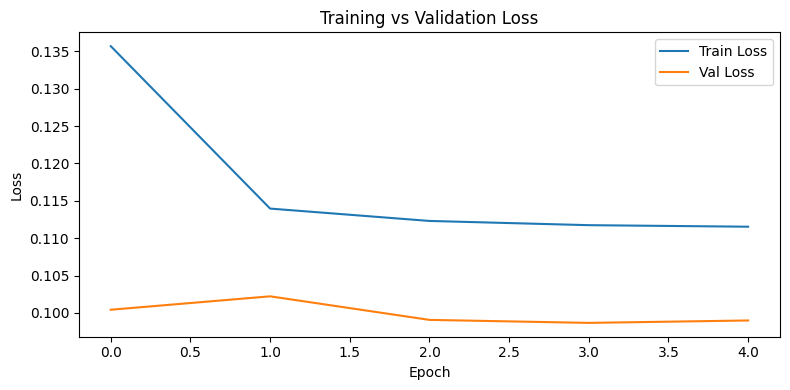

rmse : 9.9071
mae  : 6.2393


In [ ]:
plot_losses(train_losses, val_losses)
preds, targets = test(model, test_loader, mean, std, device)

In [ ]:
from torch_geometric.nn import GCNConv

class TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2)

    def forward(self, x):
        # x: [N, T, C]
        x = x.transpose(1, 2)  # [N, C, T]
        x = self.conv(x)
        return x.transpose(1, 2)


class STGCNBlock(nn.Module):
    def __init__(self, hidden_feats):
        super().__init__()
        self.temp1 = TemporalConv(hidden_feats, hidden_feats)
        self.spatial = GCNConv(hidden_feats, hidden_feats)
        self.temp2 = TemporalConv(hidden_feats, hidden_feats)

    def forward(self, x, edge_index):
        # x: [N, T, H]
        x = self.temp1(x)

        # apply GCN per timestep
        out = []
        for t in range(x.size(1)):
            out.append(self.spatial(x[:, t, :], edge_index))
        x = torch.stack(out, dim=1)

        x = self.temp2(x)
        return x


class STGCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_layers=2, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Linear(1, hidden_feats)

        self.blocks = nn.ModuleList([
            STGCNBlock(hidden_feats) for _ in range(num_layers)
        ])

        self.fc = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_feats, out_feats),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = x.unsqueeze(-1)              # [N, T, 1]
        x = self.input_proj(x)           # [N, T, H]

        for block in self.blocks:
            x = block(x, edge_index)

        x = x[:, -1, :]                  # last timestep
        return self.fc(x)

In [ ]:
class DilatedTemporalConv(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()
        self.conv = nn.Conv1d(
            channels, channels,
            kernel_size=2,
            dilation=dilation,
            padding=dilation
        )

    def forward(self, x):
        return self.conv(x)


class GraphWaveNetLayer(nn.Module):
    def __init__(self, hidden_feats, dropout):
        super().__init__()
        self.filter_conv = DilatedTemporalConv(hidden_feats, dilation=1)
        self.gate_conv   = DilatedTemporalConv(hidden_feats, dilation=1)

        self.gcn = GCNConv(hidden_feats, hidden_feats)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # x: [N, H, T]
        residual = x

        filter_out = torch.tanh(self.filter_conv(x))
        gate_out   = torch.sigmoid(self.gate_conv(x))
        x = filter_out * gate_out

        x = x.transpose(1, 2)  # [N, T, H]

        out = []
        for t in range(x.size(1)):
            out.append(self.gcn(x[:, t, :], edge_index))
        x = torch.stack(out, dim=1)

        x = x.transpose(1, 2)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return x + residual


class GraphWaveNet(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_layers=3, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Linear(1, hidden_feats)

        self.layers = nn.ModuleList([
            GraphWaveNetLayer(hidden_feats, dropout)
            for _ in range(num_layers)
        ])

        self.fc = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_feats, out_feats),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = x.unsqueeze(-1)          # [N, T, 1]
        x = self.input_proj(x)       # [N, T, H]
        x = x.transpose(1, 2)        # [N, H, T]

        for layer in self.layers:
            x = layer(x, edge_index)

        x = x[:, :, -1]              # last timestep
        return self.fc(x)